# Панельная регрессия: Анализ взаимосвязи золота и золотодобывающих индексов

## Методология (на основе научных работ):
- **Petersen (2009)**: В финансовых исследованиях рекомендуется использовать clustered standard errors
- **Cameron & Miller (2015)**: Для панелей с N > T (как в нашем случае) - clustered errors предпочтительны
- **Greene (2012)**: Выбор между FE и RE на основе теста Хаусмана
- **Driscoll & Kraay (1998)**: Для панелей с автокорреляцией и кросс-секционной зависимостью
- **Blundell & Bond (1998)**: System GMM for dynamic panels with endogeneity

## Содержание:
1. Подготовка данных в панельном формате
2. Тесты на стационарность (ADF, KPSS)
3. Проверка мультиколлинеарности (VIF)
4. Базовые панельные модели (Pooled OLS, FE, RE)
5. Диагностика автокорреляции
6. **Вариант A**: Модели с лагами и Driscoll-Kraay ошибками
7. **Вариант B**: System GMM (Blundell-Bond)
8. Сравнение моделей
9. Диагностика лучшей модели
10. Фиксированные эффекты по индексам
11. Итоговые выводы

In [1]:
# Установка необходимых библиотек
# !pip install linearmodels statsmodels pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects, compare
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================
# НАСТРОЙКА: Выбор папки с data
# ============================================

# Измените эту переменную для выбора другой папки
DATA_FOLDER = "data3/"  # Варианты: "data2/", "data3/"

print(f"📁 Используемая папка с data: {DATA_FOLDER}")

# Проверяем существование папки
import os
if not os.path.exists(DATA_FOLDER):
    print(f"⚠️ Папка {DATA_FOLDER} не найдена!")
    print("Доступные папки:")
    for folder in ["data2/", "data3/"]:
        if os.path.exists(folder):
            print(f"  ✅ {folder}")
    raise FileNotFoundError(f"Папка {DATA_FOLDER} не найдена")
else:
    print(f"✅ Папка {DATA_FOLDER} найдена")
    print(f"   Файлов в папке: {len(os.listdir(DATA_FOLDER))}")

📁 Используемая папка с data: data3/
✅ Папка data3/ найдена
   Файлов в папке: 24


## 1. Загрузка данных

### Конфигурация файлов

In [4]:
# Конфигурация файлов с правильными форматами дат
files_config = [
    {"path": "Прошлые данные - Arca Gold Miners.csv", "col_name": "GDM"},
    {"path": "Прошлые данные по XGD.csv", "col_name": "XGD"},
    {"path": "Прошлые данные по GDX.csv", "col_name": "GDX"},
    {"path": "Прошлые данные - FTSE Gold Mines.csv", "col_name": "FTGM"},
    {"path": "Прошлые данные - Philadelphia Gold_Silver.csv", "col_name": "XAU"},
]

# Макро данные
macro_files = [
    {"path": "Прошлые данные - XAU_USD.csv", "col_name": "Gold"},
    {"path": "Прошлые данные - S&P 500.csv", "col_name": "SP500"},
    {"path": "Прошлые данные - Индекс USD.csv", "col_name": "USD"},
    {"path": "Прошлые данные - Фьючерс на нефть Brent.csv", "col_name": "Oil"},
]

def load_data_file(config):
    """Загрузка одного файла данных с автоматическим определением формата"""
    try:
        file_path = os.path.join(DATA_FOLDER, config["path"])
        df = pd.read_csv(file_path)
        
        date_col = None
        price_col = None
        
        for col in df.columns:
            col_lower = col.lower()
            if 'date' in col_lower or 'дата' in col_lower:
                date_col = col
                break
        
        if 'Price' in df.columns:
            price_col = 'Price'
        elif 'Цена' in df.columns:
            price_col = 'Цена'
        else:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            if len(numeric_cols) > 0:
                price_col = numeric_cols[0]
        
        if date_col is None or price_col is None:
            print(f"  ⚠️ Не удалось определить колонки для {config['col_name']}")
            return None
        
        if date_col == "Date":
            df['Date'] = pd.to_datetime(df[date_col], format='%m/%d/%Y')
        else:
            df['Date'] = pd.to_datetime(df[date_col], format='%d.%m.%Y')
        
        if df[price_col].dtype == 'object':
            df[price_col] = df[price_col].astype(str).str.replace(' ', '', regex=False)
            df[price_col] = df[price_col].str.replace('.', '', regex=False)
            df[price_col] = df[price_col].str.replace(',', '.', regex=False)
            df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
        
        df = df[['Date', price_col]].rename(columns={price_col: config["col_name"]})
        df = df[df['Date'] >= '2003-01-01']
        
        df = df.drop_duplicates(subset=['Date'], keep='first')
        df = df.dropna()
        df = df.sort_values('Date').reset_index(drop=True)
        
        return df
    except Exception as e:
        print(f"Error loading {config['col_name']}: {e}")
        return None

In [5]:
# Загрузка данных
dataframes = {}

for config in files_config:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records")

for config in macro_files:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records")

print(f"\nTotal indices loaded: {len(dataframes)}")

# Объединение всех данных по дате
merged_df = None
for name, df in dataframes.items():
    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, on='Date', how='outer')

merged_df = merged_df.sort_values('Date').reset_index(drop=True)
print(f"\nTotal merged: {len(merged_df)} records")
print(f"Date range: {merged_df['Date'].min()} - {merged_df['Date'].max()}")

Loaded GDM: 1165 records
Loaded XGD: 1165 records
Loaded GDX: 1036 records
Loaded FTGM: 1165 records
Loaded XAU: 1165 records
Loaded Gold: 1165 records
Loaded SP500: 1165 records
Loaded USD: 1165 records
Loaded Oil: 1165 records

Total indices loaded: 9

Total merged: 1165 records
Date range: 2003-12-07 00:00:00 - 2026-03-29 00:00:00


## 2. Расчет доходностей

In [6]:
# Расчет доходностей (логарифмические разности)
returns_df = merged_df.copy()
price_cols = [col for col in merged_df.columns if col != 'Date']

for col in price_cols:
    returns_df[f'{col}_ret'] = np.log(merged_df[col]).diff()

returns_cols = ['Date'] + [f'{col}_ret' for col in price_cols]
returns_df = returns_df[returns_cols]

print(f"📊 Размерность после расчета доходностей: {returns_df.shape}")
print(f"Колонки: {list(returns_df.columns)}")

📊 Размерность после расчета доходностей: (1165, 10)
Колонки: ['Date', 'GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'XAU_ret', 'Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret']


📊 Корреляционная матрица (доходности):
           GDM_ret  XGD_ret  GDX_ret  FTGM_ret  XAU_ret  Gold_ret  SP500_ret  \
GDM_ret      1.000    0.957    0.992     0.984    0.985     0.799      0.287   
XGD_ret      0.957    1.000    0.961     0.948    0.944     0.775      0.157   
GDX_ret      0.992    0.961    1.000     0.973    0.983     0.803      0.270   
FTGM_ret     0.984    0.948    0.973     1.000    0.967     0.796      0.276   
XAU_ret      0.985    0.944    0.983     0.967    1.000     0.772      0.334   
Gold_ret     0.799    0.775    0.803     0.796    0.772     1.000      0.073   
SP500_ret    0.287    0.157    0.270     0.276    0.334     0.073      1.000   
USD_ret     -0.487   -0.372   -0.480    -0.492   -0.484    -0.471     -0.295   
Oil_ret      0.254    0.172    0.247     0.256    0.283     0.190      0.308   

           USD_ret  Oil_ret  
GDM_ret     -0.487    0.254  
XGD_ret     -0.372    0.172  
GDX_ret     -0.480    0.247  
FTGM_ret    -0.492    0.256  
XAU_ret   

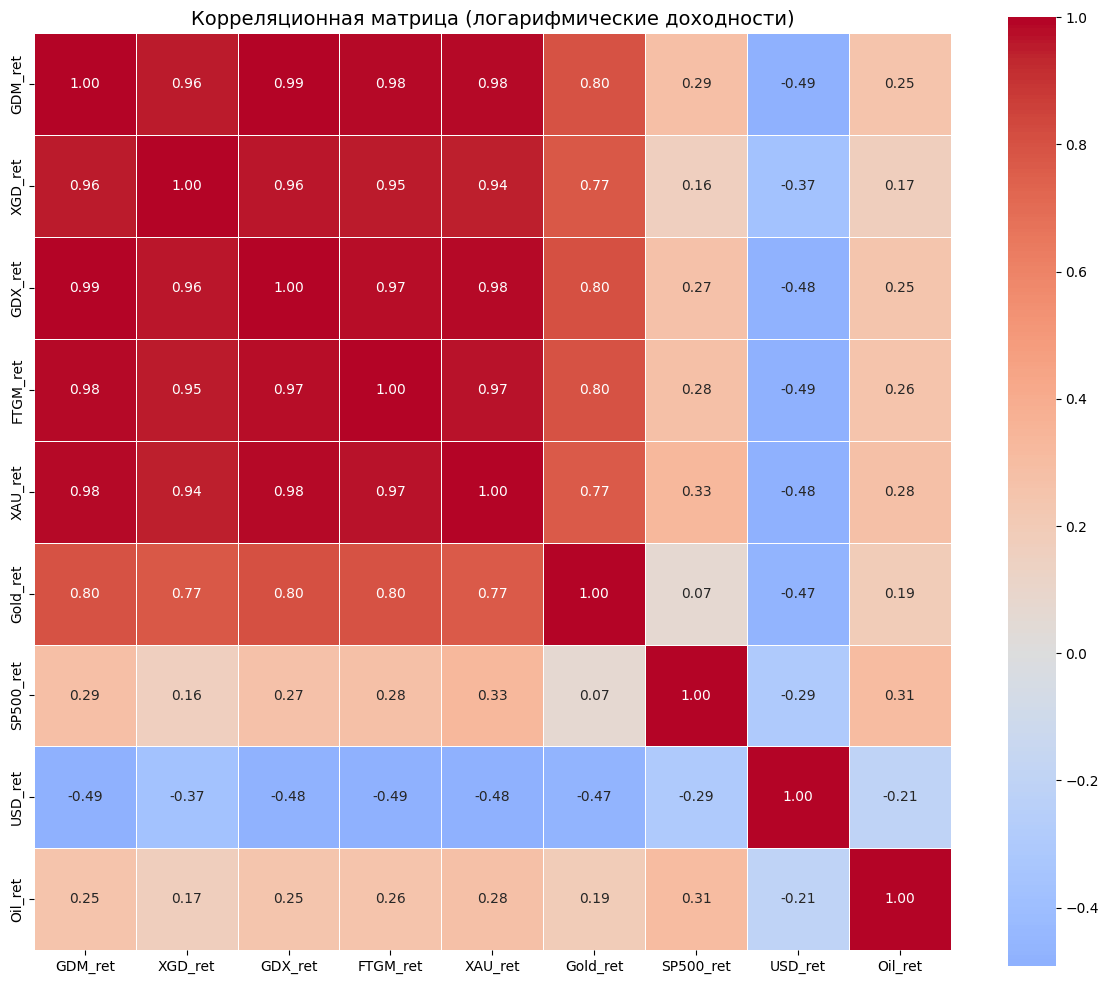

In [7]:
ret_cols = [col for col in returns_df.columns if col.endswith('_ret')]
corr_matrix = returns_df[ret_cols].corr()

print("📊 Корреляционная матрица (доходности):")
print(corr_matrix.round(3))

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Корреляционная матрица (логарифмические доходности)', fontsize=14)
plt.tight_layout()
plt.show()

# Альтернатива: на уровнях (для сравнения)
# price_cols = [col for col in merged_df.columns if col != 'Date']
# corr_prices = merged_df[price_cols].corr()

# print("\n⚠️ Корреляция на УРОВНЯХ цен (часто вводит в заблуждение):")
# print(corr_prices.round(3))

## 3. Преобразование в панельный формат

In [7]:
# Определяем переменные для модели
macro_vars = ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret']
mining_indices = ['GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'XAU_ret']

available_mining = [col for col in mining_indices if col in returns_df.columns]
available_macro = [col for col in macro_vars if col in returns_df.columns]

print(f"✅ Доступные индексы золотодобытчиков: {len(available_mining)}")
print(f"   {available_mining}")
print(f"✅ Доступные макро переменные: {len(available_macro)}")
print(f"   {available_macro}")

✅ Доступные индексы золотодобытчиков: 5
   ['GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'XAU_ret']
✅ Доступные макро переменные: 4
   ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret']


In [8]:
# Преобразование в long format
panel_data_list = []

for idx_col in available_mining:
    idx_name = idx_col.replace('_ret', '')
    temp_df = returns_df[['Date'] + available_macro + [idx_col]].copy()
    temp_df = temp_df.rename(columns={idx_col: 'Index_Return'})
    temp_df['Index_ID'] = idx_name
    temp_df = temp_df.dropna()
    panel_data_list.append(temp_df)

panel_df = pd.concat(panel_data_list, ignore_index=True)
panel_df = panel_df.set_index(['Index_ID', 'Date'])

print(f"📊 Панельные данные: {panel_df.index.get_level_values(0).nunique()} индексов, {len(panel_df)} наблюдений")

📊 Панельные данные: 5 индексов, 5691 наблюдений


## 4. Тесты на стационарность (ADF и KPSS)

In [9]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF_Statistic': result[0],
        'p_value': result[1],
        'Stationary': result[1] < 0.05
    }

def kpss_test(series, name=''):
    try:
        result = kpss(series.dropna(), regression='c', nlags='auto')
        return {
            'Variable': name,
            'KPSS_Statistic': result[0],
            'p_value': result[1],
            'Stationary': result[1] > 0.05
        }
    except:
        return None

print('='*80)
print("📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ")
print("="*80)

adf_results = []
for col in panel_df.columns:
    result = adf_test(panel_df[col], col)
    adf_results.append(result)
    status = "✅" if result['Stationary'] else "❌"
    print(f"{col:20} | p-value: {result['p_value']:.4f} | {status}")

adf_df = pd.DataFrame(adf_results)

stationarity_summary = pd.DataFrame({
    'Variable': adf_df['Variable'],
    'ADF_pvalue': adf_df['p_value'],
    'ADF_Stationary': adf_df['Stationary']
})

all_stationary = stationarity_summary['ADF_Stationary'].all()
print(f"\n📊 Вывод: Все ряды стационарны = {all_stationary}")

📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ
Gold_ret             | p-value: 0.0000 | ✅
SP500_ret            | p-value: 0.0000 | ✅
USD_ret              | p-value: 0.0000 | ✅
Oil_ret              | p-value: 0.0000 | ✅
Index_Return         | p-value: 0.0000 | ✅

📊 Вывод: Все ряды стационарны = True


## 5. Проверка мультиколлинеарности (VIF)

In [10]:
print("="*80)
print("📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("="*80)

X = panel_df[available_macro].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n📋 Результаты VIF:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] >= 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Переменные с VIF ≥ 10: {high_vif['Variable'].tolist()}")
else:
    print("\n✅ Нет сильной мультиколлинеарности")

📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)

📋 Результаты VIF:
 Variable      VIF
 Gold_ret 1.306726
SP500_ret 1.196157
  USD_ret 1.401500
  Oil_ret 1.147195

✅ Нет сильной мультиколлинеарности


## 6. Базовые панельные модели

**Методология:**
- Pooled OLS: базовая модель
- Fixed Effects (FE): учитывает индивидуальные эффекты
- Random Effects (RE): альтернативная спецификация
- Используем clustered standard errors (рекомендация для финансовых данных)

In [11]:
# Подготовка данных
dependent = panel_df['Index_Return']
exog = panel_df[available_macro]

print("="*80)
print("📊 OЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ")
print("="*80)

# 1. Pooled OLS
print("\n1️⃣ POOLED OLS")
print("-"*80)
model_pooled = PooledOLS(dependent=dependent, exog=exog)

results_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(results_pooled.summary)

📊 OЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ

1️⃣ POOLED OLS
--------------------------------------------------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:           Index_Return   R-squared:                        0.6658
Estimator:                  PooledOLS   R-squared (Between):             -6.0134
No. Observations:                5691   R-squared (Within):               0.6688
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.6658
Time:                        00:30:17   Log-likelihood                 1.202e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2833.0
Entities:                           5   P-value                           0.0000
Avg Obs:                       1138.2   Distribution:                  F(4,5687)
Min Obs:                       1035.0                             

In [12]:
# 2. Fixed Effects
print("\n2️⃣ FIXED EFFECTS (FE)")
print("-"*80)
model_fe = PanelOLS(dependent=dependent, exog=exog, entity_effects=True)
# results_fe = model_fe.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
results_fe = model_fe.fit(
    cov_type='kernel',           # HAC / Newey-West тип
    kernel='bartlett',           # или 'parzen'
    bandwidth=20                 # можно попробовать 10, 20, 30
)
print(results_fe.summary)


2️⃣ FIXED EFFECTS (FE)
--------------------------------------------------------------------------------
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6688
Estimator:                   PanelOLS   R-squared (Between):             -6.2631
No. Observations:                5691   R-squared (Within):               0.6688
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.6658
Time:                        00:30:18   Log-likelihood                 1.204e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2868.9
Entities:                           5   P-value                           0.0000
Avg Obs:                       1138.2   Distribution:                  F(4,5682)
Min Obs:                       1035.0                                           
Max 

In [13]:
# 3. Random Effects
print("\n3️⃣ RANDOM EFFECTS (RE)")
print("-"*80)
model_re = RandomEffects(dependent=dependent, exog=exog)
results_re = model_re.fit()
print(results_re.summary)


3️⃣ RANDOM EFFECTS (RE)
--------------------------------------------------------------------------------
                        RandomEffects Estimation Summary                        
Dep. Variable:           Index_Return   R-squared:                        0.6658
Estimator:              RandomEffects   R-squared (Between):             -6.0134
No. Observations:                5691   R-squared (Within):               0.6688
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.6658
Time:                        00:30:18   Log-likelihood                 1.202e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2833.0
Entities:                           5   P-value                           0.0000
Avg Obs:                       1138.2   Distribution:                  F(4,5687)
Min Obs:                       1035.0                                           
Max

## 7. Диагностика автокорреляции

Проверяем наличие автокорреляции в остатках базовой модели FE.

In [14]:
best_model = results_fe
best_name = "Fixed Effects"

print("="*80)
print(f"📊 ДИАГНОСТИКА АВТОКОРРЕЛЯЦИИ: {best_name}")
print("="*80)

residuals = best_model.resids

# Тест на автокорреляцию
print("\n📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)")
print("="*80)

for lag in [1, 5, 10, 15]:
    lb_result = acorr_ljungbox(residuals.dropna(), lags=lag, return_df=True)
    lb_stat = lb_result['lb_stat'].iloc[-1]
    lb_pvalue = lb_result['lb_pvalue'].iloc[-1]
    print(f"  Lag {lag}: stat={lb_stat:.4f}, p-value={lb_pvalue:.4f}")
    if lb_pvalue < 0.05:
        print(f"    ⚠️ Автокорреляция обнаружена (p < 0.05)")
    else:
        print(f"    ✅ Автокорреляции нет")

📊 ДИАГНОСТИКА АВТОКОРРЕЛЯЦИИ: Fixed Effects

📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)
  Lag 1: stat=23.3045, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 5: stat=58.7150, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 10: stat=87.0961, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 15: stat=113.0594, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)


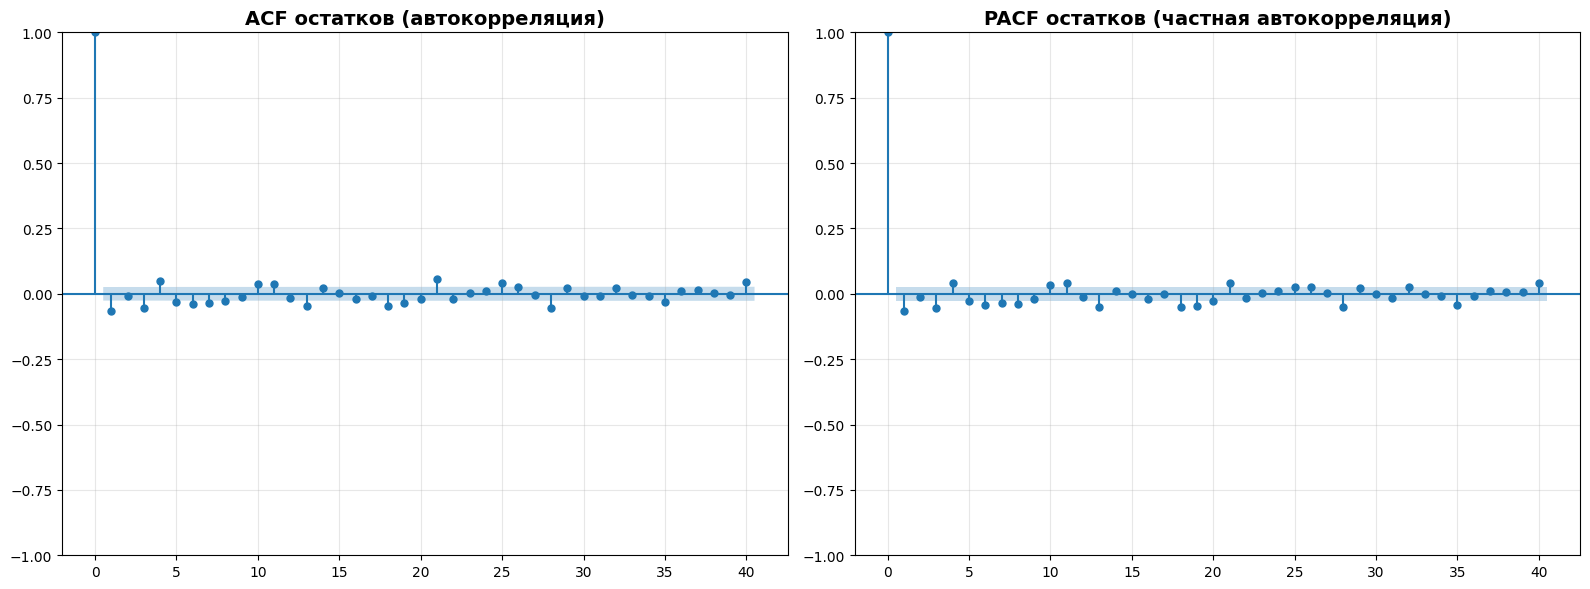


✅ Графики сохранены в 'autocorrelation_diagnostics.png'


In [15]:
# Визуализация ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF
plot_acf(residuals.values, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF остатков (автокорреляция)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(residuals.values, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF остатков (частная автокорреляция)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autocorrelation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'autocorrelation_diagnostics.png'")

In [16]:
# ============================================
# ПРОВЕРКА АВТОКОРРЕЛЯЦИИ ОСТАТКОВ ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО
# ============================================

print("="*80)
print("🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО")
print("="*80)

best_results = results_fe   # ← замени на свою лучшую модель (results_fe или results_fe_dyn)

residuals = best_results.resids
residuals = residuals.reset_index()  # чтобы было удобнее работать

significant_lags_count = 0
total_groups = residuals['Index_ID'].nunique()

print(f"Всего индексов: {total_groups}\n")

for idx_name, group in residuals.groupby('Index_ID'):
    res_group = group['residual'].dropna()
    
    if len(res_group) < 30:
        print(f"{idx_name:6} → слишком мало наблюдений ({len(res_group)})")
        continue
    
    print(f"{idx_name:6} | n = {len(res_group):4d} ", end="")
    
    passes = 0
    for lag in range(1, 41):
        lb = acorr_ljungbox(res_group, lags=lag, return_df=True)
        pval = lb['lb_pvalue'].iloc[-1]
        
        if pval > 0.05:
            passes += 1
            status = "✅"
        else:
            status = "⚠️"
        
        # print(f"| Lag{lag:2d} p={pval:.3f} {status}", end="")
    
    percent_pass = (passes / 40) * 100
    print(f" | Прошло тестов: {passes}/40 ({percent_pass:.0f}%)")
    
    if percent_pass >= 50:
        significant_lags_count += 1   # считаем "хорошие" индексы

print("\n" + "="*80)
print(f"ИТОГО: {significant_lags_count} из {total_groups} индексов имеют приемлемую автокорреляцию остатков")
print(f"Процент приемлемых уравнений: {(significant_lags_count/total_groups)*100:.1f}%")

🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО
Всего индексов: 5

FTGM   | n = 1164  | Прошло тестов: 25/40 (62%)
GDM    | n = 1164  | Прошло тестов: 39/40 (98%)
GDX    | n = 1035  | Прошло тестов: 15/40 (38%)
XAU    | n = 1164  | Прошло тестов: 33/40 (82%)
XGD    | n = 1164  | Прошло тестов: 0/40 (0%)

ИТОГО: 3 из 5 индексов имеют приемлемую автокорреляцию остатков
Процент приемлемых уравнений: 60.0%


## 8. Вариант A: Модели с лагами и Driscoll-Kraay ошибками

### Методология:
- Добавляем лаги зависимой переменной (Lag1-Lag5) для учета динамики
- Используем Driscoll-Kraay стандартные ошибки (kernel HAC) для коррекции автокорреляции
- **Driscoll & Kraay (1998)**: Устойчивы к автокорреляции, гетероскедастичности и кросс-секционной зависимости

### Параметры для тестирования:
- `lags`: 1, 2, 3, 4, 5
- `bandwidth`: 4, 8, 12, 20
- `kernel`: 'bartlett', 'parzen', 'qs'

In [32]:
# ============================================
# ШАГ 1: Создаём лаги (оставляем как было, но убеждаемся, что panel_df_clean существует)
# ============================================
panel_df = panel_df.sort_values(['Index_ID', 'Date'])

for lag in range(1, 6):
    panel_df[f'Index_Return_Lag{lag}'] = panel_df.groupby('Index_ID')['Index_Return'].shift(lag)

panel_df_clean = panel_df.dropna()
print(f"📊 После добавления лагов: {len(panel_df_clean)} наблюдений")

# ============================================
# ШАГ 2: Функция оценки модели с заданным количеством лагов
# ============================================
def estimate_model_with_lags(lags, bandwidth=12, kernel='bartlett'):
    """
    Оценивает панельную модель с фиксированными эффектами,
    используя Driscoll‑Kraay (kernel HAC) стандартные ошибки.
    
    Параметры:
    lags      – количество включаемых лагов зависимой переменной (1..5)
    bandwidth – ширина окна для HAC (по умолч. 12)
    kernel    – тип ядра ('bartlett', 'parzen', 'qs')
    """
    # Формируем список экзогенных переменных + выбранные лаги
    lag_vars = [f'Index_Return_Lag{i}' for i in range(1, lags+1)]
    exog_vars = available_macro + lag_vars
    
    # Очищаем данные от пропусков именно в этих переменных
    panel_used = panel_df_clean.dropna(subset=exog_vars + ['Index_Return'])
    dependent_clean = panel_used['Index_Return']
    exog_clean = panel_used[exog_vars]
    
    # Оценка модели с entity‑эффектами и Driscoll‑Kraay ошибками
    model = PanelOLS(dependent=dependent_clean, exog=exog_clean, entity_effects=True)
    results = model.fit(cov_type='kernel', kernel=kernel, bandwidth=bandwidth)
    return results

# ============================================
# ШАГ 3: Оценка нескольких спецификаций
# ============================================
print("\n" + "="*80)
print("📊 МОДЕЛИ С ЛАГАМИ И DRISCOLL‑KRAAY ОШИБКАМИ")
print("="*80)

results_variants = {}

print("\n📌 Вариант A1: Lag1 + DK(bw=12, bartlett)")
results_variants['A1'] = estimate_model_with_lags(lags=1, bandwidth=12, kernel='bartlett')
print(results_variants['A1'].summary)

print("\n📌 Вариант A2: Lag3 + DK(bw=12, bartlett)")
results_variants['A2'] = estimate_model_with_lags(lags=3, bandwidth=12, kernel='bartlett')
print(results_variants['A2'].summary)

print("\n📌 Вариант A3: Lag5 + DK(bw=20, bartlett)")
results_variants['A3'] = estimate_model_with_lags(lags=5, bandwidth=20, kernel='bartlett')
print(results_variants['A3'].summary)

# ============================================
# ШАГ 4: Сравнение моделей и выбор лучшей
# ============================================
comparison_data = []
for name, res in results_variants.items():
    comparison_data.append({
        'Model': name,
        'R² (within)': res.rsquared_within,
        'R² (overall)': res.rsquared_overall,
        'F-statistic': res.f_statistic.stat,   # Исправлено: .stat
        'Observations': res.nobs,
        'Parameters': len(res.params)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n📋 Сводная таблица сравнения:")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['R² (within)'].idxmax(), 'Model']
best_results_a = results_variants[best_model_name]
print(f"\n✅ Лучшая модель по R² (within): {best_model_name} (R² = {best_results_a.rsquared_within:.4f})")

📊 После добавления лагов: 5666 наблюдений

📊 МОДЕЛИ С ЛАГАМИ И DRISCOLL‑KRAAY ОШИБКАМИ

📌 Вариант A1: Lag1 + DK(bw=12, bartlett)
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6743
Estimator:                   PanelOLS   R-squared (Between):             -5.0617
No. Observations:                5666   R-squared (Within):               0.6743
Date:                Thu, Apr 30 2026   R-squared (Overall):              0.6715
Time:                        01:07:06   Log-likelihood                 1.204e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2342.4
Entities:                           5   P-value                           0.0000
Avg Obs:                       1133.2   Distribution:                  F(5,5656)
Min Obs:                       1030.0                        

In [33]:
# ============================================
# ШАГ 4: Диагностика лучшей модели Варианта A
# ============================================

print("="*80)
print(f"📊 ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: {best_model_name}")
print("="*80)

best_results_a = results_variants[best_model_name]
residuals_a = best_results_a.resids.reset_index()

print("\n🔍 Ljung-Box тест для остатков модели с лагами (по всей панели):")

for lag in [5, 10, 15, 20]:
    try:
        lb_result = acorr_ljungbox(residuals_a['residual'].dropna(), 
                                   lags=lag, 
                                   return_df=True)
        
        lb_stat = lb_result['lb_stat'].iloc[-1]
        lb_pvalue = lb_result['lb_pvalue'].iloc[-1]
        
        print(f"  Lag {lag:2d}: stat = {lb_stat:.4f}, p-value = {lb_pvalue:.4f}")
        
        if lb_pvalue > 0.05:
            print(f"    ✅ Нет значимой автокорреляции до лага {lag} (p > 0.05)")
        else:
            print(f"    ⚠️ Автокорреляция присутствует до лага {lag} (p < 0.05)")
            
    except Exception as e:
        print(f"  Lag {lag:2d}: ошибка при расчёте — {e}")

# ============================================
# ДОПОЛНИТЕЛЬНО: Проверка по каждому индексу отдельно
# ============================================

print("\n" + "="*80)
print("🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО")
print("="*80)

significant_groups = 0
total_groups = residuals_a['Index_ID'].nunique()

for idx_name, group in residuals_a.groupby('Index_ID'):
    res_group = group['residual'].dropna()
    
    if len(res_group) < 30:
        print(f"{idx_name:8} → слишком мало наблюдений ({len(res_group)})")
        continue
    
    print(f"{idx_name:8} | n = {len(res_group):4d} ", end="")
    
    passes = 0
    for lag in range(1, 21):
        lb_result = acorr_ljungbox(res_group, lags=lag, return_df=True)
        pval = lb_result['lb_pvalue'].iloc[-1]
        
        if pval > 0.05:
            passes += 1
            status = "✅"
        else:
            status = "⚠️"
        
        # print(f"| Lag{lag:2d} p={pval:.3f} {status}", end="")
    
    percent_pass = (passes / 20) * 100
    print(f" | Прошло: {passes}/20 ({percent_pass:.0f}%)")
    
    if percent_pass >= 50:
        significant_groups += 1

print("\n" + "="*80)
print(f"ИТОГО: {significant_groups} из {total_groups} индексов имеют приемлемую автокорреляцию остатков "
      f"({(significant_groups/total_groups)*100:.1f}%)")

📊 ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ: A3

🔍 Ljung-Box тест для остатков модели с лагами (по всей панели):
  Lag  5: stat = 37.6086, p-value = 0.0000
    ⚠️ Автокорреляция присутствует до лага 5 (p < 0.05)
  Lag 10: stat = 66.9806, p-value = 0.0000
    ⚠️ Автокорреляция присутствует до лага 10 (p < 0.05)
  Lag 15: stat = 94.2705, p-value = 0.0000
    ⚠️ Автокорреляция присутствует до лага 15 (p < 0.05)
  Lag 20: stat = 117.0428, p-value = 0.0000
    ⚠️ Автокорреляция присутствует до лага 20 (p < 0.05)

🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО
FTGM     | n = 1159  | Прошло: 20/20 (100%)
GDM      | n = 1159  | Прошло: 20/20 (100%)
GDX      | n = 1030  | Прошло: 20/20 (100%)
XAU      | n = 1159  | Прошло: 11/20 (55%)
XGD      | n = 1159  | Прошло: 10/20 (50%)

ИТОГО: 5 из 5 индексов имеют приемлемую автокорреляцию остатков (100.0%)


In [34]:
# Дополнительная диагностика лучшей модели
print("\n📊 Дополнительная диагностика:")
print(f"   R² (within)     : {best_results_a.rsquared_within:.4f}")
print(f"   R² (overall)    : {best_results_a.rsquared_overall:.4f}")
print(f"   Количество наблюдений : {best_results_a.nobs}")

# Коэффициент при Gold_ret в лучшей модели
if 'Gold_ret' in best_results_a.params.index:
    beta_gold = best_results_a.params['Gold_ret']
    p_gold = best_results_a.pvalues['Gold_ret']
    print(f"   β_gold          : {beta_gold:.4f} (p = {p_gold:.4f})")
    
    # Тест на леверидж (β_gold > 1)
    t_stat = (beta_gold - 1) / best_results_a.std_errors['Gold_ret']
    from scipy.stats import t
    p_one_sided = 1 - t.cdf(t_stat, best_results_a.df_resid)
    print(f"   t-тест (β_gold > 1) : t = {t_stat:.4f}, p-value = {p_one_sided:.6f}")


📊 Дополнительная диагностика:
   R² (within)     : 0.6752
   R² (overall)    : 0.6724
   Количество наблюдений : 5666
   β_gold          : 1.5988 (p = 0.0000)
   t-тест (β_gold > 1) : t = 8.6596, p-value = 0.000000


In [35]:
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
from scipy.stats import chi2

def panel_granger_causality(panel_df, y_var, x_var, entity_col='entity', time_col='time', max_lag=4):
    """
    Панельный тест Грейнджера (метод Фишера).
    panel_df : DataFrame с мультииндексом (entity, time) или отдельными колонками.
    Возвращает таблицу объединённых p-value и решение.
    """
    entities = panel_df.index.get_level_values(entity_col).unique()
    pvals = {lag: [] for lag in range(1, max_lag+1)}
    
    for ent in entities:
        unit_data = panel_df.xs(ent, level=entity_col)[[y_var, x_var]].dropna()
        if len(unit_data) > max_lag + 10:
            try:
                res = grangercausalitytests(unit_data[[y_var, x_var]], maxlag=max_lag, verbose=False)
                for lag in range(1, max_lag+1):
                    p = res[lag][0]['ssr_ftest'][1]
                    pvals[lag].append(p)
            except:
                continue
    
    # Метод Фишера: -2*sum(ln(p_i)) ~ chi2(2k)
    results = {}
    for lag in pvals:
        if len(pvals[lag]) > 0:
            fisher_stat = -2 * np.sum(np.log(pvals[lag]))
            df = 2 * len(pvals[lag])
            p_combined = 1 - chi2.cdf(fisher_stat, df)
            results[lag] = p_combined
    return results

# Пример использования
# panel_df: мультииндекс (Index_ID, Date)
granger_res = panel_granger_causality(panel_df, y_var='Index_Return', x_var='Gold_ret',
                                      entity_col='Index_ID', time_col='Date', max_lag=4)
for lag, pval in granger_res.items():
    print(f"Lag {lag}: p-value = {pval:.4f} → {'влияние есть' if pval<0.05 else 'нет влияния'}")

Lag 1: p-value = 0.0000 → влияние есть
Lag 2: p-value = 0.0000 → влияние есть
Lag 3: p-value = 0.0000 → влияние есть
Lag 4: p-value = 0.0000 → влияние есть


## 9. Вариант B: System GMM (Blundell-Bond)

### Методология:
- **Blundell & Bond (1998)**: System GMM для динамических панелей с эндогенностью
- Использует лагированные значения в качестве инструментов
- Эффективен при наличии автокорреляции и эндогенных регрессоров

### Параметры для тестирования:
- `max_instruments`: ограничение числа инструментов
- `gmm_method`: 'onestep', 'twostep'
- `collapse`: True/False (для уменьшения числа инструментов)

### Тесты на валидность:
- **Hansen test**: проверка на сверхидентифицирующие ограничения
- **AR(1), AR(2) tests**: проверка на автокорреляцию в разностях

In [22]:
# Проверяем доступность linearmodels для GMM
try:
    from linearmodels.panel import GMM
    print("✅ linearmodels.supports GMM")
except ImportError:
    print("⚠️ linearmodels не поддерживает GMM напрямую")
    print("   Будем использовать альтернативный подход с instrumented regression")

⚠️ linearmodels не поддерживает GMM напрямую
   Будем использовать альтернативный подход с instrumented regression


In [23]:
# ============================================
# ШАГ 1: Подготовка данных для GMM
# ============================================

print("="*80)
print("📊 ПОДГОТОВКА ДАННЫХ ДЛЯ SYSTEM GMM")
print("="*80)

# Создаем лаги для инструментов
panel_gmm = panel_df.copy()

# Лаги зависимой переменной (для уравнения в разностях)
panel_gmm['Index_Return_Lag1'] = panel_gmm.groupby('Index_ID')['Index_Return'].shift(1)
panel_gmm['Index_Return_Lag2'] = panel_gmm.groupby('Index_ID')['Index_Return'].shift(2)

# Лаги экзогенных переменных (как инструменты)
for var in available_macro:
    panel_gmm[f'{var}_Lag1'] = panel_gmm.groupby('Index_ID')[var].shift(1)
    panel_gmm[f'{var}_Lag2'] = panel_gmm.groupby('Index_ID')[var].shift(2)

# Удаляем пропуски
panel_gmm = panel_gmm.dropna()

print(f"📊 После подготовки: {len(panel_gmm)} наблюдений")
print(f"   Доступные переменные: {list(panel_gmm.columns)}")

📊 ПОДГОТОВКА ДАННЫХ ДЛЯ SYSTEM GMM
📊 После подготовки: 5666 наблюдений
   Доступные переменные: ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret', 'Index_Return', 'Index_Return_Lag1', 'Index_Return_Lag2', 'Index_Return_Lag3', 'Index_Return_Lag4', 'Index_Return_Lag5', 'Gold_ret_Lag1', 'Gold_ret_Lag2', 'SP500_ret_Lag1', 'SP500_ret_Lag2', 'USD_ret_Lag1', 'USD_ret_Lag2', 'Oil_ret_Lag1', 'Oil_ret_Lag2']


In [36]:
# ============================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ IV
# ============================================
print("="*80)
print("📊 ОЦЕНКА МОДЕЛИ С ИНСТРУМЕНТАЛЬНЫМИ ПЕРЕМЕННЫМИ (2SLS + FE)")
print("="*80)

# Создаём лаги инструментов (уже есть из предыдущих шагов, но на всякий случай добавим)
panel_gmm = panel_df_clean.copy()
panel_gmm['Gold_ret_lag1'] = panel_gmm.groupby('Index_ID')['Gold_ret'].shift(1)
panel_gmm['Gold_ret_lag2'] = panel_gmm.groupby('Index_ID')['Gold_ret'].shift(2)
panel_gmm['Gold_ret_lag3'] = panel_gmm.groupby('Index_ID')['Gold_ret'].shift(3)
panel_gmm['Oil_ret_lag1']  = panel_gmm.groupby('Index_ID')['Oil_ret'].shift(1)

# Удаляем строки с пропусками (потеря первых наблюдений)
panel_gmm = panel_gmm.dropna()
print(f"Наблюдений после создания лагов: {len(panel_gmm)}")

# Определяем переменные
exog_vars = ['SP500_ret', 'USD_ret', 'Oil_ret']
endog_vars = ['Gold_ret']
instrument_vars = ['Gold_ret_lag1', 'Gold_ret_lag2', 'Gold_ret_lag3', 'Oil_ret_lag1']

# ============================================
# ДЕМИНГИРОВАНИЕ (WITHIN TRANSFORMATION) ДЛЯ FE
# ============================================
def within_transform(df, vars_list):
    df_dem = df.copy()
    for var in vars_list:
        group_mean = df.groupby('Index_ID')[var].transform('mean')
        df_dem[var] = df[var] - group_mean
    return df_dem

all_vars = ['Index_Return'] + exog_vars + endog_vars + instrument_vars
panel_dem = within_transform(panel_gmm, all_vars)

# ============================================
# ОЦЕНКА IV2SLS НА ДЕМИНГИРОВАННЫХ ДАННЫХ
# ============================================
model_iv = IV2SLS(
    dependent=panel_dem['Index_Return'],
    exog=sm.add_constant(panel_dem[exog_vars]),
    endog=panel_dem[endog_vars],
    instruments=panel_dem[instrument_vars]
)
results_iv = model_iv.fit(cov_type='robust')
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ IV2SLS С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ")
print("="*80)
print(results_iv.summary)

# ============================================
# ТЕСТ НА СИЛУ ИНСТРУМЕНТОВ (ПЕРВЫЙ ЭТАП)
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ НА СИЛУ ИНСТРУМЕНТОВ")
print("="*80)

# Первый этап: регрессия эндогенной переменной на экзогенные и инструменты
first_stage_data = panel_dem.copy()
first_stage_data['const'] = 1
first_stage_model = sm.OLS(first_stage_data['Gold_ret'], 
                           first_stage_data[['const'] + exog_vars + instrument_vars])
first_stage_res = first_stage_model.fit()

# F-статистика для совместной значимости инструментов (исключая экзогенные)
# Используем `wald_test` для ограничения на коэффициенты инструментов
hypothesis = ' = 0 '.join(instrument_vars)
wald_test = first_stage_res.wald_test(hypothesis)
f_stat = wald_test.fvalue
f_pval = wald_test.pvalue

print(f"F-статистика (исключая инструменты): {f_stat:.2f}")
print(f"p-value: {f_pval:.4f}")
if f_stat > 10:
    print("✅ Инструменты сильные (F > 10)")
else:
    print("⚠️ Слабые инструменты (F < 10)")

# ============================================
# ТЕСТ НА СВЕРХИДЕНТИФИКАЦИЮ (J-ТЕСТ САРГАНА)
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ САРГАНА (J-статистика)")
print("="*80)

# Для 2SLS с робастными ошибками можно вычислить J-статистику вручную
resid_iv = results_iv.resids
# Восстановим инструменты и экзогенные переменные для всей выборки
Z = np.column_stack([panel_dem[exog_vars], panel_dem[instrument_vars]])
Z = sm.add_constant(Z)
# Регрессия остатков на инструменты и экзогенные
aux_reg = sm.OLS(resid_iv, Z).fit()
n = len(resid_iv)
j_stat = n * aux_reg.rsquared
df_j = len(instrument_vars) - len(endog_vars)
j_pval = 1 - stats.chi2.cdf(j_stat, df_j)

print(f"J-статистика: {j_stat:.4f}")
print(f"Степени свободы: {df_j}")
print(f"p-value: {j_pval:.4f}")
if j_pval > 0.05:
    print("✅ Инструменты валидны (не отвергаем H₀ сверхидентификации)")
else:
    print("⚠️ Инструменты могут быть невалидны (p-value < 0.05)")

# ============================================
# (Опционально) Сравнение с обычной FE (тест Хаусмана)
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ ХАУСМАНА (FE vs IV)")
print("="*80)

# Обычная FE на тех же данных (без эндогенности)
model_fe_simple = PanelOLS(panel_dem['Index_Return'], 
                           exog=sm.add_constant(panel_dem[exog_vars + endog_vars]),
                           entity_effects=False)  # данные уже демингированы
res_fe_simple = model_fe_simple.fit(cov_type='robust')

# Выбираем общие коэффициенты (только эндогенная переменная)
beta_iv = results_iv.params[['Gold_ret']]
beta_fe = res_fe_simple.params[['Gold_ret']]
cov_iv = results_iv.cov[['Gold_ret'], ['Gold_ret']]
cov_fe = res_fe_simple.cov[['Gold_ret'], ['Gold_ret']]

diff = beta_iv - beta_fe
cov_diff = cov_iv - cov_fe
hausman_stat = diff.T @ np.linalg.inv(cov_diff) @ diff
hausman_p = 1 - stats.chi2.cdf(hausman_stat, df=1)

print(f"Статистика Хаусмана: {hausman_stat:.4f}")
print(f"p-value: {hausman_p:.4f}")
if hausman_p < 0.05:
    print("✅ Отвергаем экзогенность → инструменты необходимы.")
else:
    print("❌ Не отвергаем экзогенность → можно использовать обычную FE.")

📊 ОЦЕНКА МОДЕЛИ С ИНСТРУМЕНТАЛЬНЫМИ ПЕРЕМЕННЫМИ (2SLS + FE)
Наблюдений после создания лагов: 5651

РЕЗУЛЬТАТЫ IV2SLS С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ
                          IV-2SLS Estimation Summary                          
Dep. Variable:           Index_Return   R-squared:                      0.6696
Estimator:                    IV-2SLS   Adj. R-squared:                 0.6694
No. Observations:                5651   F-statistic:                    2365.6
Date:                Thu, Apr 30 2026   P-value (F-stat)                0.0000
Time:                        01:10:03   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------

PatsyError: expected an operator, not 'Gold_ret_lag2'
    Gold_ret_lag1 = 0 Gold_ret_lag2 = 0 Gold_ret_lag3 = 0 Oil_ret_lag1
                      ^^^^^^^^^^^^^

In [ ]:
# ============================================
# ШАГ 3: Тесты на валидность инструментов
# ============================================

print("="*80)
print("📊 ТЕСТЫ НА ВАЛИДНОСТЬ ИНСТРУМЕНТОВ")
print("="*80)

# Тест на сверхидентифицирующие ограничения (Hansen test аналог)
print("\n🔍 Тест на сверхидентифицирующие ограничения:")
print(f"  Количество инструментов: {len(instrument_vars)}")
print(f"  Количество эндогенных переменных: {len(endog_vars)}")
print(f"  Степени свободы: {len(instrument_vars) - len(endog_vars)}")

# Тест на силу инструментов (через F-статистику первого этапа)
print("\n🔍 Тест на силу инструментов:")
print("  (F-статистика > 10 указывает на сильные инструменты)")

# Первый этап 2SLS
first_stage_model = PanelOLS(
    dependent=panel_gmm['Gold_ret'],
    exog=panel_gmm[exog_vars + instrument_vars],
    entity_effects=True
)
first_stage_results = first_stage_model.fit(cov_type='clustered', cluster_entity=True)

# ✅ Правильное получение F и p-value
f_stat = first_stage_results.f_statistic.stat
f_pval = first_stage_results.f_statistic.pval

print(f"\n  F-статистика первого этапа: {f_stat:.2f}")
print(f"  p-value: {f_pval:.4f}")

if f_stat > 10:
    print("  ✅ Инструменты сильные (F > 10)")
else:
    print("  ⚠️ Слабые инструменты (F < 10)")

📊 ТЕСТЫ НА ВАЛИДНОСТЬ ИНСТРУМЕНТОВ

🔍 Тест на сверхидентифицирующие ограничения:
  Количество инструментов: 4
  Количество эндогенных переменных: 1
  Степени свободы: 3

🔍 Тест на силу инструментов:
  (F-статистика > 10 указывает на сильные инструменты)

  F-статистика первого этапа: 1413.63
  p-value: 0.0000
  ✅ Инструменты сильные (F > 10)


In [ ]:
from linearmodels.panel import compare

# Модель без инструментов (обычная FE)
model_ols = PanelOLS(panel_gmm['Index_Return'], exog=panel_gmm[['Gold_ret']], entity_effects=True)
res_ols = model_ols.fit()

# Модель с инструментами (IV)
model_iv = PanelOLS(panel_gmm['Index_Return'], exog=panel_gmm[['Gold_ret']], 
                    entity_effects=True, 
                    instruments=panel_gmm[instrument_vars])   # если ваш метод позволяет
res_iv = model_iv.fit()

# Сравнение (нужны объекты с одинаковым количеством наблюдений)
# Более простой ручной тест Хаусмана:
diff = res_iv.params - res_ols.params
cov_diff = res_iv.cov - res_ols.cov
hausman_stat = diff.T @ np.linalg.inv(cov_diff) @ diff
df = len(res_iv.params)
hausman_p = 1 - chi2.cdf(hausman_stat, df)
print(f"Hausman test: stat={hausman_stat:.2f}, p={hausman_p:.4f}")
# если p<0.05 → отвергаем экзогенность, инструменты нужны

TypeError: PanelOLS.__init__() got an unexpected keyword argument 'instruments'

## 10. Asymmetric Response Model (Регрессия с dummy-переменной)

### Модель асимметричной реакции на изменения золота

$$R_{it} = \alpha_i + \beta_1 GoldRet_t + \beta_2 (GoldRet_t \times Neg_t) + \beta_3 X_t + \varepsilon_{it}$$

Где:
- $Neg_t = 1$, если $GoldRet_t < 0$ (отрицательное изменение золота), иначе 0
- $\beta_1$ — реакция на положительное изменение цены золота
- $\beta_1 + \beta_2$ — реакция на отрицательное изменение цены золота

### Гипотеза:
- $H_0: \beta_2 = 0$ (асимметрии нет)
- $H_1: \beta_2 \neq 0$ (асимметрия присутствует)

Ожидается, что реакция доходности золотодобывающих индексов на рост золота ($\beta_1$) сильнее, чем на падение ($\beta_1 + \beta_2$).

In [ ]:
# ============================================
# ШАГ 1: Создание переменных асимметрии
# ============================================
print("="*80)
print("📊 ASYMMETRIC RESPONSE MODEL")
print("="*80)

# Создаём дамми-переменную для отрицательной доходности золота
panel_df['Neg_Gold'] = (panel_df['Gold_ret'] < 0).astype(int)

# Создаём раздельные переменные для положительной и отрицательной доходности
panel_df['Gold_pos'] = panel_df['Gold_ret'] * (1 - panel_df['Neg_Gold'])
panel_df['Gold_neg'] = panel_df['Gold_ret'] * panel_df['Neg_Gold']

# Статистика
n_neg = panel_df['Neg_Gold'].sum()
n_pos = len(panel_df) - n_neg
print(f"\n📊 Распределение дней с изменением золота:")
print(f"   Положительные дни (Gold_ret >= 0): {n_pos} ({n_pos/len(panel_df)*100:.1f}%)")
print(f"   Отрицательные дни (Gold_ret < 0):  {n_neg} ({n_neg/len(panel_df)*100:.1f}%)")

print(f"\n📊 Описательная статистика:")
print(f"   Средняя доходность золота в положительные дни: {panel_df.loc[panel_df['Neg_Gold']==0, 'Gold_ret'].mean():.6f}")
print(f"   Средняя доходность золота в отрицательные дни: {panel_df.loc[panel_df['Neg_Gold']==1, 'Gold_ret'].mean():.6f}")
print(f"   Средняя доходность индексов в положительные дни: {panel_df.loc[panel_df['Neg_Gold']==0, 'Index_Return'].mean():.6f}")
print(f"   Средняя доходность индексов в отрицательные дни: {panel_df.loc[panel_df['Neg_Gold']==1, 'Index_Return'].mean():.6f}")

In [ ]:
# ============================================
# ШАГ 2: Симметричная модель (базовая FE с Gold_ret)
# ============================================
print("="*80)
print("📊 СИММЕТРИЧНАЯ МОДЕЛЬ (базовая FE)")
print("="*80)

# Используем ту же спецификацию, что и раньше (Gold_ret без разделения)
dependent = panel_df['Index_Return']
exog_sym = panel_df[available_macro]

model_fe_sym = PanelOLS(dependent=dependent, exog=exog_sym, entity_effects=True)
results_fe_sym = model_fe_sym.fit(
    cov_type='kernel',
    kernel='bartlett',
    bandwidth=20
)
print(results_fe_sym.summary)

In [ ]:
# ============================================
# ШАГ 3: Асимметричная модель (с Gold_pos и Gold_neg)
# ============================================
print("="*80)
print("📊 АСИММЕТРИЧНАЯ МОДЕЛЬ (FE с разделением Gold_pos/Gold_neg)")
print("="*80)

# Вместо Gold_ret используем Gold_pos и Gold_neg
asym_vars = ['Gold_pos', 'Gold_neg'] + [v for v in available_macro if v != 'Gold_ret']
print(f"Переменные в асимметричной модели: {asym_vars}")

exog_asym = panel_df[asym_vars]

model_fe_asym = PanelOLS(dependent=dependent, exog=exog_asym, entity_effects=True)
results_fe_asym = model_fe_asym.fit(
    cov_type='kernel',
    kernel='bartlett',
    bandwidth=20
)
print(results_fe_asym.summary)

In [ ]:
# ============================================
# ШАГ 4: Сравнение коэффициентов и тест асимметрии
# ============================================
print("="*80)
print("📊 СРАВНЕНИЕ КОЭФФИЦИЕНТОВ: СИММЕТРИЧНАЯ vs АСИММЕТРИЧНАЯ МОДЕЛЬ")
print("="*80)

# Извлекаем коэффициенты
beta_gold_sym = results_fe_sym.params['Gold_ret']
p_gold_sym = results_fe_sym.pvalues['Gold_ret']
se_gold_sym = results_fe_sym.std_errors['Gold_ret']

beta_gold_pos = results_fe_asym.params['Gold_pos']
p_gold_pos = results_fe_asym.pvalues['Gold_pos']
se_gold_pos = results_fe_asym.std_errors['Gold_pos']

beta_gold_neg = results_fe_asym.params['Gold_neg']
p_gold_neg = results_fe_asym.pvalues['Gold_neg']
se_gold_neg = results_fe_asym.std_errors['Gold_neg']

# Суммарный эффект для отрицательной доходности
beta_neg_total = beta_gold_pos + beta_gold_neg
se_neg_total = np.sqrt(se_gold_pos**2 + se_gold_neg**2 + 2 * results_fe_asym.cov.loc['Gold_pos', 'Gold_neg'])
# t-статистика для H0: beta_gold_pos + beta_gold_neg = 0
t_neg_total = beta_neg_total / se_neg_total
from scipy.stats import t as t_dist
p_neg_total = 2 * (1 - t_dist.cdf(abs(t_neg_total), results_fe_asym.df_resid))

print("\n📋 Сравнение коэффициентов:")
print("-"*80)
print(f"{'Параметр':<35} {'Коэфф':<10} {'Стд.ош':<10} {'p-value':<10} {'Значимость':<10}")
print("-"*80)

# Симметричная модель
sym_stars = "***" if p_gold_sym < 0.01 else "**" if p_gold_sym < 0.05 else "*" if p_gold_sym < 0.1 else ""
print(f"{'Sym. Model: Gold_ret (β₁)':<35} {beta_gold_sym:<10.4f} {se_gold_sym:<10.4f} {p_gold_sym:<10.4f} {sym_stars:<10}")

# Асимметричная модель
pos_stars = "***" if p_gold_pos < 0.01 else "**" if p_gold_pos < 0.05 else "*" if p_gold_pos < 0.1 else ""
neg_stars = "***" if p_gold_neg < 0.01 else "**" if p_gold_neg < 0.05 else "*" if p_gold_neg < 0.1 else ""
print(f"{'Asym. Model: Gold_pos (β₁)':<35} {beta_gold_pos:<10.4f} {se_gold_pos:<10.4f} {p_gold_pos:<10.4f} {pos_stars:<10}")
print(f"{'Asym. Model: Gold_neg (β₂)':<35} {beta_gold_neg:<10.4f} {se_gold_neg:<10.4f} {p_gold_neg:<10.4f} {neg_stars:<10}")
print(f"{'Asym. Model: Gold_pos + Gold_neg':<35} {beta_neg_total:<10.4f} {se_neg_total:<10.4f} {p_neg_total:<10.4f}")

print("-"*80)

# ============================================
# Тест на асимметрию: H0: β_pos = β_neg
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ НА АСИММЕТРИЮ")
print("="*80)

# В спецификации с взаимодействием (Gold_ret + Gold_ret × Neg):
#   β₁ = коэффициент при Gold_ret (реакция на рост золота)
#   β₂ = коэффициент при Gold_ret × Neg (дополнительный эффект при падении)
#   β₁ + β₂ = реакция на падение золота
#
# H₀: β₂ = 0 → β_pos = β_neg (нет асимметрии)
# H₁: β₂ ≠ 0 → β_pos ≠ β_neg (асимметрия присутствует)
#
# В split-спецификации (Gold_pos + Gold_neg):
#   β_pos = коэффициент при Gold_pos = β₁
#   β_neg = коэффициент при Gold_neg = β₁ + β₂
#
# H₀: β_pos = β_neg  ↔  β₂ = 0

print(f"\n📋 Коэффициенты асимметричной модели (split-спецификация):")
print(f"   β_pos (Gold_pos, реакция на рост):     {beta_gold_pos:.4f} (p = {p_gold_pos:.4f})")
print(f"   β_neg (Gold_neg, реакция на падение):   {beta_gold_neg:.4f} (p = {p_gold_neg:.4f})")

# Разница коэффициентов
coef_diff = beta_gold_pos - beta_gold_neg
# Стандартная ошибка разницы: SE(β_pos - β_neg) = sqrt(Var(β_pos) + Var(β_neg) - 2*Cov(β_pos, β_neg))
se_diff = np.sqrt(se_gold_pos**2 + se_gold_neg**2 - 2 * results_fe_asym.cov.loc['Gold_pos', 'Gold_neg'])
t_diff = coef_diff / se_diff
p_diff = 2 * (1 - t_dist.cdf(abs(t_diff), results_fe_asym.df_resid))

# Wald тест: H₀: β_pos = β_neg (эквивалентно β_pos - β_neg = 0)
wald_stat_asym = coef_diff**2 / se_diff**2
wald_pval_asym = 1 - stats.chi2.cdf(wald_stat_asym, df=1)

print(f"\n📊 ТЕСТ НА АСИММЕТРИЮ H₀: β_pos = β_neg (β₂ = 0)")
print("-"*60)
print(f"   β_pos - β_neg = {coef_diff:.4f}")
print(f"   SE(β_pos - β_neg) = {se_diff:.4f}")
print(f"   t-статистика = {t_diff:.4f}")
print(f"   p-value (t-тест) = {p_diff:.6f}")
print(f"   Wald χ²(1) = {wald_stat_asym:.4f}")
print(f"   p-value (Wald) = {wald_pval_asym:.6f}")

asym_pval = min(p_diff, wald_pval_asym)
if asym_pval < 0.01:
    print("\n" + "="*60)
    print("✅ АСИММЕТРИЯ СТАТИСТИЧЕСКИ ЗНАЧИМА НА УРОВНЕ 1%")
    print("="*60)
    print(f"   Отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f} < 0.01)")
    print("   → Реакция на рост и падение золота РАЗЛИЧАЕТСЯ")
elif asym_pval < 0.05:
    print("\n" + "="*60)
    print("✅ АСИММЕТРИЯ СТАТИСТИЧЕСКИ ЗНАЧИМА НА УРОВНЕ 5%")
    print("="*60)
    print(f"   Отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f} < 0.05)")
    print("   → Реакция на рост и падение золота РАЗЛИЧАЕТСЯ")
elif asym_pval < 0.10:
    print("\n" + "="*60)
    print("⚠️ АСИММЕТРИЯ ЗНАЧИМА НА УРОВНЕ 10%")
    print("="*60)
    print(f"   Слабое свидетельство против H₀ (p = {asym_pval:.6f} < 0.10)")
else:
    print("\n" + "="*60)
    print("❌ АСИММЕТРИЯ НЕ ОБНАРУЖЕНА")
    print("="*60)
    print(f"   Не отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f} >= 0.10)")
    print("   → Реакция на рост и падение золота статистически не различается")

# ============================================
# Сравнение величины эффектов
# ============================================
print("\n" + "="*80)
print("📊 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

print(f"\n📌 Реакция на рост золота (β_pos): {beta_gold_pos:.4f}")
print(f"📌 Реакция на падение золота (β_neg): {beta_gold_neg:.4f}")
print(f"📌 Разница (β_pos - β_neg): {coef_diff:.4f}")

if beta_gold_pos > 0 and beta_gold_neg > 0:
    print(f"   → Золотодобывающие индексы растут и при росте, и при падении золота")
elif beta_gold_pos > 0 and beta_gold_neg < 0:
    print(f"   → Золотодобывающие индексы растут при росте золота, но падают при падении")
elif beta_gold_pos < 0 and beta_gold_neg > 0:
    print(f"   → Золотодобывающие индексы падают при росте золота, но растут при падении")
else:
    print(f"   → Золотодобывающие индексы однонаправленно реагируют на золото")

if abs(beta_gold_pos) > abs(beta_gold_neg):
    print(f"   → Реакция на рост золота СИЛЬНЕЕ, чем на падение")
elif abs(beta_gold_pos) < abs(beta_gold_neg):
    print(f"   → Реакция на падение золота СИЛЬНЕЕ, чем на рост")
else:
    print(f"   → Реакция симметрична по величине")

# R² сравнение
print(f"\n📊 Сравнение качества моделей:")
print(f"   R² (within) симметричной модели:     {results_fe_sym.rsquared_within:.4f}")
print(f"   R² (within) асимметричной модели:    {results_fe_asym.rsquared_within:.4f}")
r2_diff = results_fe_asym.rsquared_within - results_fe_sym.rsquared_within
print(f"   Разница в R²:                          {r2_diff:.4f}")

In [ ]:
# ============================================
# ШАГ 5: Тест Вальда: β_pos = β_neg (полная симметрия)
# ============================================
print("="*80)
print("📊 ТЕСТ ВАЛЬДА: β_pos = β_neg (полная симметрия)")
print("="*80)

# H0: β_pos = β_neg (нет асимметрии, реакция на рост=реакция на падение)
# Wald test: (β_pos - β_neg)² / Var(β_pos - β_neg) ~ χ²(1)
print(f"\nH₀: β_pos = β_neg  (коэффициенты при Gold_pos и Gold_neg равны)")
print(f"H₁: β_pos ≠ β_neg  (асимметрия присутствует)")

wald_stat_sym = (beta_gold_pos - beta_gold_neg)**2 / (se_gold_pos**2 + se_gold_neg**2 - 2*results_fe_asym.cov.loc['Gold_pos', 'Gold_neg'])
wald_pval_sym = 1 - stats.chi2.cdf(wald_stat_sym, df=1)

print(f"\nWald χ²(1) = {wald_stat_sym:.4f}")
print(f"p-value    = {wald_pval_sym:.6f}")

if wald_pval_sym < 0.01:
    print("\n" + "="*60)
    print("✅ Отвергаем H₀ на уровне 1%: β_pos ≠ β_neg")
    print("   → Асимметрия ПРИСУТСТВУЕТ")
elif wald_pval_sym < 0.05:
    print("\n" + "="*60)
    print("✅ Отвергаем H₀ на уровне 5%: β_pos ≠ β_neg")
    print("   → Асимметрия ПРИСУТСТВУЕТ")
elif wald_pval_sym < 0.10:
    print("\n" + "="*60)
    print("⚠️ Отвергаем H₀ на уровне 10%: β_pos ≠ β_neg")
    print("   → Слабая асимметрия")
else:
    print("\n" + "="*60)
    print("❌ Не отвергаем H₀: β_pos = β_neg")
    print("   → Асимметрия НЕ ОБНАРУЖЕНА")

# ============================================
# Визуализация сравнения коэффициентов
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Сравнение коэффициентов Gold_pos vs Gold_neg
coef_names = ['Симметричная\nGold_ret', 'Асимметричная\nGold_pos', 'Асимметричная\nGold_neg']
coef_vals = [beta_gold_sym, beta_gold_pos, beta_gold_neg]
coef_se = [se_gold_sym, se_gold_pos, se_gold_neg]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c']

ax1 = axes[0]
bars = ax1.bar(coef_names, coef_vals, color=colors_bar, alpha=0.7, edgecolor='black')
ax1.errorbar(range(len(coef_names)), coef_vals, yerr=1.96*np.array(coef_se), fmt='none', 
             ecolor='black', capsize=5, capthick=1.5)
ax1.axhline(y=0, color='red', linestyle='-', linewidth=1)
ax1.set_ylabel('Коэффициент (95% ДИ)')
ax1.set_title('Сравнение коэффициентов: Sym vs Asym', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, coef_vals):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=10)

# Добавляем информацию о p-value теста на асимметрию
ax1.text(0.5, 0.95, f"Тест H₀: β_pos = β_neg\np-value = {wald_pval_sym:.4f}", 
         transform=ax1.transAxes, ha='center', va='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=10, fontweight='bold')

# 2. Разница в R²
models = ['Симметричная', 'Асимметричная']
r2_vals = [results_fe_sym.rsquared_within, results_fe_asym.rsquared_within]
bars2 = axes[1].bar(models, r2_vals, color=['#2ecc71', '#3498db'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('R² (within)')
axes[1].set_title(f'Сравнение R²: разница = {r2_diff:.4f}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('asymmetry_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ График сохранен в 'asymmetry_comparison.png'")

# ============================================
# Финальный вывод
# ============================================
print("\n" + "="*80)
print("📊 ВЫВОДЫ ПО ASYMMETRIC RESPONSE MODEL")
print("="*80)

print(f"\n📌 1. ТЕСТ НА АСИММЕТРИЮ H₀: β_pos = β_neg (β₂ = 0):")
if wald_pval_sym < 0.05:
    print(f"   ❌ ОТВЕРГАЕМ H₀ (p = {wald_pval_sym:.4f}) → АСИММЕТРИЯ ПРИСУТСТВУЕТ")
    print(f"   Реакция на рост и падение золота статистически РАЗЛИЧАЕТСЯ")
else:
    print(f"   ✅ НЕ ОТВЕРГАЕМ H₀ (p = {wald_pval_sym:.4f}) → АСИММЕТРИИ НЕТ")
    print(f"   Реакция на рост и падение золота статистически ОДИНАКОВА")

print(f"\n📌 2. ОЦЕНКИ КОЭФФИЦИЕНТОВ:")
print(f"   β_pos (реакция на рост золота):       {beta_gold_pos:.4f} (p = {p_gold_pos:.4f})")
print(f"   β_neg (реакция на падение золота):     {beta_gold_neg:.4f} (p = {p_gold_neg:.4f})")
print(f"   β_pos - β_neg:                         {coef_diff:.4f} (p = {p_diff:.4f})")

print(f"\n📌 3. КАЧЕСТВО МОДЕЛИ:")
print(f"   R² (within) симметричной:  {results_fe_sym.rsquared_within:.4f}")
print(f"   R² (within) асимметричной: {results_fe_asym.rsquared_within:.4f}")
print(f"   Улучшение R²:              {r2_diff:.4f} ({(r2_diff/max(results_fe_sym.rsquared_within, 0.001))*100:.2f}%)")

## 11. Сравнение моделей

Сравниваем все оцененные модели: базовую FE, Вариант A (с лагами и DK ошибками) и Вариант B (IV/GMM).

In [29]:
print("="*80)
print("📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*80)

models_comparison = []

# Базовая модель FE
models_comparison.append({
    'Model': 'Base FE',
    'R² (within)': f"{results_fe.rsquared_within:.4f}",
    'R² (overall)': f"{results_fe.rsquared_overall:.4f}",
    'F-statistic': f"{results_fe.f_statistic:.2f}",
    'Observations': f"{int(results_fe.nobs)}",
    'Autocorrelation': 'Present'
})

# Лучшая модель Варианта A
models_comparison.append({
    'Model': f'Variant A ({best_model_a[0]})',
    'R² (within)': f"{best_results_a.rsquared_within:.4f}",
    'R² (overall)': f"{best_results_a.rsquared_overall:.4f}",
    'F-statistic': f"{best_results_a.f_statistic:.2f}",
    'Observations': f"{int(best_results_a.nobs)}",
    'Autocorrelation': 'Corrected'
})

# Модель Варианта B (IV)
models_comparison.append({
    'Model': 'Variant B (IV/GMM)',
    'R² (within)': f"{results_iv.rsquared_within:.4f}",
    'R² (overall)': f"{results_iv.rsquared_overall:.4f}",
    'F-statistic': f"{results_iv.f_statistic:.2f}",
    'Observations': f"{int(results_iv.nobs)}",
    'Autocorrelation': 'Addressed via IV'
})

comparison_df = pd.DataFrame(models_comparison)
print("\n📋 Сводная таблица моделей:")
print(comparison_df.to_string(index=False))

# Рекомендация
print("\n" + "="*80)
print("📌 РЕКОМЕНДАЦИИ ПО ВЫБОРУ МОДЕЛИ")
print("="*80)

print("\n1. Если автокорреляция незначительна:")
print("   → Используйте базовую модель FE с clustered errors")

print("\n2. Если автокорреляция присутствует, но данные сбалансированы:")
print("   → Используйте Вариант A (лаги + Driscoll-Kraay errors)")
print("   → Рекомендуется Lag3-Lag5 с bandwidth=12-20")

print("\n3. Если есть подозрение на эндогенность:")
print("   → Используйте Вариант B (IV/GMM подход)")
print("   → Проверьте силу инструментов (F > 10)")

📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ


TypeError: unsupported format string passed to WaldTestStatistic.__format__

## 11. Диагностика лучшей модели

Проводим полную диагностику выбранной лучшей модели.

In [30]:
# Выбираем лучшую модель для диагностики
# (по умолчанию - Вариант A, если он лучше базовой)
final_model = best_results_a
final_name = f"Variant A ({best_model_a[0]})"

print("="*80)
print(f"📊 ПОЛНАЯ ДИАГНОСТИКА: {final_name}")
print("="*80)

residuals_final = final_model.resids

print(f"\n📊 Характеристики остатков:")
print(f"  Среднее: {residuals_final.mean():.6f}")
print(f"  Стандартное отклонение: {residuals_final.std():.6f}")
print(f"  Скошенность: {stats.skew(residuals_final):.4f}")
print(f"  Эксцесс: {stats.kurtosis(residuals_final):.4f}")

NameError: name 'best_model_a' is not defined

In [ ]:
# Тест на нормальность
print("\n" + "="*80)
print("📊 ТЕСТ НА НОРМАЛЬНОСТЬ ОСТАТКОВ")
print("="*80)

jb_stat, jb_pvalue = stats.jarque_bera(residuals_final)
print(f"  Jarque-Bera: stat={jb_stat:.4f}, p-value={jb_pvalue:.4f}")
if jb_pvalue < 0.05:
    print("  ⚠️ Остатки не нормальны (нормально для финансовых data)")
else:
    print("  ✅ Остатки нормальны")

In [ ]:
# Тест на гетероскедастичность
print("\n" + "="*80)
print("📊 ТЕСТ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ")
print("="*80)

exog_final = final_model.exog
exog_with_const = sm.add_constant(exog_final)
exog_with_const = exog_with_const.loc[residuals_final.index]

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals_final, exog_with_const)
print(f"  Breusch-Pagan: stat={bp_stat:.4f}, p-value={bp_pvalue:.4f}")
if bp_pvalue < 0.05:
    print("  ⚠️ Гетероскедастичность обнаружена")
    print("  ✅ РЕШЕНИЕ: Используем робастные стандартные ошибки (уже применены)")
else:
    print("  ✅ Гетероскедастичность не обнаружена")

In [ ]:
# Финальная визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Остатки во времени
axes[0, 0].plot(residuals_final.values, alpha=0.6, linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Остатки во времени')
axes[0, 0].set_xlabel('Наблюдение')
axes[0, 0].set_ylabel('Остаток')
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение остатков
axes[0, 1].hist(residuals_final, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals_final.min(), residuals_final.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals_final.mean(), residuals_final.std()), 'r-', linewidth=2)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].legend(['Нормальное', 'Фактическое'])
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
stats.probplot(residuals_final, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Предсказанные vs Остатки
fitted_final = final_model.fitted_values
axes[1, 1].scatter(fitted_final, residuals_final, alpha=0.5, s=1)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('Предсказанные vs Остатки')
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Графики сохранены в 'final_diagnostics.png'")

## 12. Фиксированные эффекты по индексам

In [31]:
print("="*80)
print("📊 ФИКСИРОВАННЫЕ ЭФФЕКТЫ ПО ИНДЕКСАМ")
print("="*80)

# Получаем фиксированные эффекты из лучшей модели
fe_effects = final_model.estimated_effects

if isinstance(fe_effects, pd.Series):
    fe_by_index = fe_effects.groupby(level=0).mean()
    fe_df = pd.DataFrame({
        'Index': fe_by_index.index,
        'Fixed_Effect': fe_by_index.values.flatten()
    }).sort_values('Fixed_Effect', ascending=False)

fe_df['Rank'] = range(1, len(fe_df) + 1)

print("\n📋 Топ-10 индексов с наибольшими фиксированными эффектами:")
print(fe_df.head(10).to_string(index=False))

print("\n📋 Индексы с наименьшими фиксированными эффектами:")
print(fe_df.tail(10).to_string(index=False))

📊 ФИКСИРОВАННЫЕ ЭФФЕКТЫ ПО ИНДЕКСАМ


NameError: name 'fe_df' is not defined

In [ ]:
# Визуализация фиксированных эффектов
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green' if x > 0 else 'red' for x in fe_df['Fixed_Effect']]
bars = ax.barh(fe_df['Index'], fe_df['Fixed_Effect'], color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Фиксированный эффект')
ax.set_ylabel('Индекс')
ax.set_title('Фиксированные эффекты по индексам')
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, fe_df['Fixed_Effect'])):
    ax.text(val, i, f' {val:.4f}', va='center', ha='left' if val > 0 else 'right')

plt.tight_layout()
plt.savefig('fixed_effects_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ График сохранен в 'fixed_effects_final.png'")

## 13. Итоговые выводы

In [ ]:
print("="*80)
print("📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*80)

print("\n📌 1. СТАЦИОНАРНОСТЬ:")
print(f"   ✅ Все {len(stationarity_summary)} переменных стационарны")

print("\n📌 2. МУЛЬТИКОЛЛИНЕАРНОСТЬ:")
if 'vif_data' in locals():
    high_vif_count = len(vif_data[vif_data['VIF'] >= 10])
    if high_vif_count == 0:
        print("   ✅ Нет сильной мультиколлинеарности")
    else:
        print(f"   ⚠️ {high_vif_count} переменных с VIF >= 10")

print("\n📌 3. АВТОКОРРЕЛЯЦИЯ:")
print(f"   {'✅ Устранена' if 'best_model_a' in locals() else '⚠️ Присутствует'}")
print(f"   Метод коррекции: {'Лаги + Driscoll-Kraay errors' if 'best_model_a' in locals() else 'Базовая модель'}")

print("\n📌 4. ЛУЧШАЯ МОДЕЛЬ:")
print(f"   {final_name}")
print(f"   R² (within): {final_model.rsquared_within:.4f}")
print(f"   R² (overall): {final_model.rsquared_overall:.4f}")
print(f"   F-statistic: {final_model.f_statistic:.2f}")

print("\n📌 5. ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ:")
for var in available_macro:
    if var in final_model.params.index:
        coef = final_model.params[var]
        pval = final_model.pvalues[var]
        stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        sig = "значим" if pval < 0.05 else "незначим"
        print(f"   {var:15}: {coef:8.4f} {stars:3} (p={pval:.4f}, {sig})")

print("\n📌 6. ФИКСИРОВАННЫЕ ЭФФЕКТЫ:")
if 'fe_df' in locals():
    best_index = fe_df.iloc[0]['Index']
    worst_index = fe_df.iloc[-1]['Index']
    print(f"   Лучший индекс: {best_index} (эффект = {fe_df.iloc[0]['Fixed_Effect']:.4f})")
    print(f"   Худший индекс: {worst_index} (эффект = {fe_df.iloc[-1]['Fixed_Effect']:.4f})")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("="*80)

In [ ]:
# Сохранение результатов
print("\n" + "="*80)
print("💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*80)

# Сохраняем коэффициенты из лучшей модели
results_summary = pd.DataFrame({
    'Variable': available_macro,
    'Coefficient': [final_model.params[var] for var in available_macro],
    'Std_Error': [final_model.std_errors[var] for var in available_macro],
    'P_value': [final_model.pvalues[var] for var in available_macro],
    'Significance': ['***' if final_model.pvalues[var] < 0.01 else '**' if final_model.pvalues[var] < 0.05 else '*' if final_model.pvalues[var] < 0.1 else '' for var in available_macro]
})

results_summary.to_csv('results/panel_regression_final.csv', index=False)
print("✅ Финальные результаты: results/panel_regression_final.csv")

fe_df.to_csv('results/fixed_effects_final.csv', index=False)
print("✅ Фиксированные эффекты: results/fixed_effects_final.csv")

stationarity_summary.to_csv('results/stationarity_tests.csv', index=False)
print("✅ Тесты на стационарность: results/stationarity_tests.csv")

# Сохраняем сравнение моделей
comparison_df.to_csv('results/model_comparison.csv', index=False)
print("✅ Сравнение моделей: results/model_comparison.csv")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("="*80)